# Electrostriction and the elasto-optic tensor

Notebook 19 computed the dielectric constant, a second derivative of the energy with
respect to an electric field. This one differentiates it once more, with respect to a
strain, which gives electrostriction: the quadratic electromechanical coupling that every
dielectric has, and the reason a capacitor deforms under a field whether or not it is
piezoelectric.

Four coefficient families describe the effect, and all of them are derivatives of the
susceptibility $\chi$ or the stiffness $\eta = \chi^{-1}$ with respect to a mechanical
variable:

$$ \varepsilon_0\,\frac{\partial \chi_{ij}}{\partial x_{kl}} = -2\,m_{ijkl},
\qquad
\frac{1}{\varepsilon_0}\frac{\partial \eta_{ij}}{\partial x_{kl}} = 2\,q_{ijkl} $$

with the stress-derivative pair $M$ and $Q$ following through the elastic compliance. This
is the thermodynamic route of Tanner, Bousquet and Janolin
([arXiv:2012.03841](https://arxiv.org/abs/2012.03841)). The alternative, optimising the cell
under a finite field and fitting a parabola, caps the k-point density at whatever the band
gap tolerates and tangles electrostriction with non-linear piezoelectricity.

So the quantity to compute is $d\varepsilon/dx$, a **third** derivative of the energy. What
makes it affordable is the 2n+1 theorem: the second-order energy is stationary in the
first-order wavefunctions, so it can be differentiated with them held fixed, and no
second-order wavefunction is ever needed. Against a central difference of $\varepsilon$ over
re-converged strained cells, the three independent components agree to
**2 $\times$ 10⁻⁴**, which is the finite difference's own floor.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

# An unshifted k-grid, run whole under `nosym`: a shifted grid is not closed under the
# point group, so a directional response can neither be run whole on it nor symmetrised.
silicon = Calculator.from_file(CASES / "si-electrostriction.in", pseudo_dir=PSEUDO,
                               announce=False)
print("silicon, %d k-points:   E = %.9f Ry"
      % (silicon.system.kpoints.nk, silicon.get_scf().total_energy))

silicon, 8 k-points:   E = -15.614354628 Ry


## 1. One call

Inside it: the field response of notebook 19, a self-consistent **strain** response, one
further linear solve per direction for the position operator's own strain derivative, and
then the third derivative itself.

In [2]:
result = silicon.get_electrostriction()

print(f"epsilon_infinity      {np.trace(result.epsilon) / 3:.6f}")
print(f"strain response       {len(result.strain.history)} iterations, "
      f"{result.strain.average_iterations:.0f} CG steps per band per solve")

epsilon_infinity      56.292875
strain response       11 iterations, 22 CG steps per band per solve


## 2. $d\chi/dx$, and the check that nothing imposed it

Nothing here averages over the point group, so the components a cubic crystal forbids are a
measurement rather than a construction. A tensor that comes out cubic when nothing made it
cubic is the strongest statement available about a quantity with no reference to compare
against.

In [3]:
VOIGT = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
LABELS = ["11", "22", "33", "23", "13", "12"]

table = np.array([[result.dchi_dstrain[i][j][k][l] for (k, l) in VOIGT]
                  for (i, j) in VOIGT])

print("d(chi_ij)/dx_kl, Voigt rows x columns")
print("      " + "".join(f"{c:>9}" for c in LABELS))
for label, row in zip(LABELS, table):
    print(f"  {label}  " + "".join(f"{v:9.4f}" for v in row))

forbidden = np.concatenate([table[3:, :3].ravel(), table[:3, 3:].ravel()])
print(f"\nlargest component cubic symmetry forbids: "
      f"{np.abs(forbidden).max() / np.abs(table).max():.1e} of the scale")

d(chi_ij)/dx_kl, Voigt rows x columns
             11       22       33       23       13       12
  11   108.1081   8.1021   8.1021  -0.0000   0.0000  -0.0000
  22     8.1021 108.1081   8.1021  -0.0000  -0.0000  -0.0000
  33     8.1021   8.1021 108.1081  -0.0000   0.0000  -0.0000
  23     0.0000  -0.0000  -0.0000 197.0154  -0.0000   0.0000
  13     0.0000  -0.0000  -0.0000  -0.0000 197.0154  -0.0000
  12     0.0000   0.0000   0.0000  -0.0000   0.0000 197.0154

largest component cubic symmetry forbids: 2.6e-14 of the scale


## 3. The derivative *is* the slope

The figure is the whole claim in one picture. The points are $\varepsilon$ computed the
laborious way, an SCF and a dielectric response at each of five strained cells, measured
once offline and quoted here; the lines are the tangents from the single call above. An
axial strain along $x$ pulls $\varepsilon_{11}$ up thirteen times harder than
$\varepsilon_{22}$, and both slopes come out together.

central difference of the sweep   108.1021
analytic derivative               108.1081
relative difference               5.5e-05


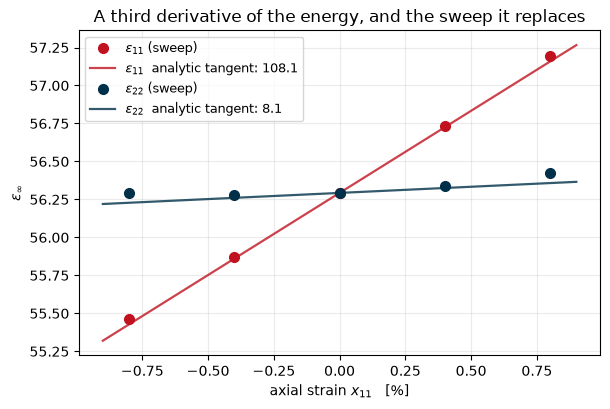

In [4]:
# Measured offline: five re-converged SCF + dielectric calculations, ~2 minutes each.
SWEEP = np.array([-0.008, -0.004, 0.0, 0.004, 0.008])
EPS_11 = np.array([55.462182, 55.868947, 56.292855, 56.733764, 57.191543])
EPS_22 = np.array([56.289746, 56.276022, 56.292855, 56.341161, 56.421977])

eps0 = float(np.trace(result.epsilon) / 3)
slope_11 = result.depsilon_dstrain[0, 0, 0, 0]
slope_22 = result.depsilon_dstrain[1, 1, 0, 0]

fig, ax = plt.subplots(figsize=(6.2, 4.2))
fine = np.linspace(-0.009, 0.009, 2)
for points, slope, colour, label in ((EPS_11, slope_11, "#c1121f", r"$\varepsilon_{11}$"),
                                     (EPS_22, slope_22, "#003049", r"$\varepsilon_{22}$")):
    ax.plot(SWEEP * 100, points, "o", color=colour, ms=7, zorder=3, label=label + " (sweep)")
    ax.plot(fine * 100, eps0 + slope * fine, "-", color=colour, lw=1.6, alpha=0.8,
            label="%s  analytic tangent: %.1f" % (label, slope))
ax.set(xlabel="axial strain $x_{11}$   [%]", ylabel=r"$\varepsilon_\infty$",
       title="A third derivative of the energy, and the sweep it replaces")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()

central = (EPS_11[3] - EPS_11[1]) / (SWEEP[3] - SWEEP[1])
print(f"central difference of the sweep   {central:.4f}")
print(f"analytic derivative               {slope_11:.4f}")
print(f"relative difference               "
      f"{abs(slope_11 - central) / abs(central):.1e}")

## 4. The number a laboratory has measured

$d\varepsilon/dx$ *is* the elasto-optic (photoelastic) tensor, up to an inversion:
$\Delta(\varepsilon^{-1})_{ij} = p_{ijkl}\,x_{kl}$, so
$p = -\varepsilon^{-1}\,(d\varepsilon/dx)\,\varepsilon^{-1}$. It is what makes a stressed
window birefringent, and it is the one quantity here with a direct measurement to sit
against.

Symmetry decides which components are a fair comparison. In the diamond structure no
internal atomic displacement is compatible with a tetragonal strain, so $p_{11}$ and
$p_{12}$ have no ionic contribution and a clamped-ion calculation is the whole answer.
$p_{44}$ carries a Kleinman internal-displacement term that is not computed here, and is
greyed out for that reason.

In [5]:
p = result.photoelastic_voigt
BIEGELSEN = {"p11": -0.094, "p12": +0.017, "p44": -0.051}   # PRL 32, 1196 (1974)

print(f"{'':6}{'pypresso':>12}{'experiment':>13}   comparable?")
for name, ours, measured in (
    ("p11", p[0, 0], BIEGELSEN["p11"]),
    ("p12", p[0, 1], BIEGELSEN["p12"]),
    ("p44", p[3, 3], BIEGELSEN["p44"]),
):
    note = "yes" if name != "p44" else "no -- needs the ionic term"
    print(f"{name:6}{ours:12.4f}{measured:13.4f}   {note}")

          pypresso   experiment   comparable?
p11        -0.0341      -0.0940   yes
p12        -0.0026       0.0170   yes
p44        -0.0622      -0.0510   no -- needs the ionic term


`p11` comes out with the right sign and within a factor of three; **`p12` does not**, at
$-0.003$ here against $+0.017$ measured, sign included. That is the k-sample rather than the
derivative: the same numbers come out of a central difference of $\varepsilon$ over
re-converged cells, and this grid gives $\varepsilon_\infty = 56$ where silicon's is 13.8.
The grid has to be closed under the point group for the symmetrisation of a directional
response to be meaningful, which keeps the sample small.

So the table is a check on the units and the algebra, not on silicon. What the notebook
establishes about the method is section 3's number: the analytic third derivative reproduces
the sweep it replaces to $5\times10^{-5}$.

## 5. The four coefficient families

$m$ and $q$ come straight from $d\chi/dx$. $M$ and $Q$, the ones that give a *strain*, which
is what experiment usually quotes, need the elastic compliance, and the elastic constants
come out of the same strain response: the second derivative of the energy with respect to a
deformation, which is the force constant matrix with the cell in place of the atoms.

In [6]:
print("elastic constants, clamped-ion (GPa)")
print(f"  C11 = {result.elastic.voigt[0, 0]:8.1f}      C12 = {result.elastic.voigt[0, 1]:8.1f}"
      f"      C44 = {result.elastic.voigt[3, 3]:8.1f}")
print(f"  B   = {result.elastic.bulk_modulus:8.1f}      "
      f"(silicon, measured: C11 165.7, C12 63.9, B 97.9)")

m_h, q_h = result.hydrostatic
big_m_h, big_q_h = result.hydrostatic_Mq
print("\nhydrostatic electrostriction coefficients")
print(f"  m_h = {m_h:10.1f} pN/V^2        q_h = {q_h:10.3f} GN m^2/C^2")
print(f"  M_h = {big_m_h:10.1f} pm^2/V^2      Q_h = {big_q_h:10.4f} m^4/C^2")

elastic constants, clamped-ion (GPa)
  C11 =    209.4      C12 =     68.0      C44 =    134.0
  B   =    115.1      (silicon, measured: C11 165.7, C12 63.9, B 97.9)

hydrostatic electrostriction coefficients
  m_h =     -550.3 pN/V^2        q_h =     -2.296 GN m^2/C^2
  M_h =     1593.7 pm^2/V^2      Q_h =     0.0066 m^4/C^2


**The elastic constants are clamped-ion, and that is the caveat to read them with.** The
ions are held at their crystallographic positions. For $C_{11}$, $C_{12}$, $p_{11}$ and
$p_{12}$ in the diamond structure that is the complete answer by symmetry, since no internal
displacement is compatible with a tetragonal strain. For $C_{44}$ and $p_{44}$ it is not,
and the missing internal relaxation is what would bring $C_{44}$ down towards the measured
79.6 GPa.

$C_{11}$ reproduces a five-point second difference of the SCF energy at the same frozen
plane-wave basis to five significant figures, which is the check that matters: the gap to
the measured 165.7 GPa is the functional, the pseudopotential and the cutoff, not the
derivative.

---
The tests behind this notebook: `tests/regression/test_electrostriction.py`. The method is
[Tanner, Bousquet & Janolin, *Small* **17**, 2103419 (2021)](https://arxiv.org/abs/2012.03841);
the strain perturbation follows
[Hamann, Wu, Rabe & Vanderbilt, PRB **71**, 035117 (2005)](https://arxiv.org/abs/cond-mat/0409269).